In [28]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import json
from functions.plot_function import (plot_joint_trajectory,
                                     plot_joints_trajectory,
                                     plot_joint_index,
                                     animate_joint_index,)
from functions.load_data import load_data, load_multi_data
from functions.load_optitrack import (load_optitrack_csv, load_multi_optitrack,
                                      set_initial_position)
import csv
import pandas as pd

In [29]:
CASE = 'flat'
FOLDER = 'cot3'
# TRIAL = [0,1,2,3,4,5,6,7,8,9]
# TRIALS = [0,1,2,3,4]
TRIALS = [99,100,101]


MODEL = "hebb"
BASE_PATH = f'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\sim2real_plot\\logs'

flat_hebb = load_multi_data(CASE, FOLDER, "hebb", TRIALS, BASE_PATH)
flat_ff = load_multi_data(CASE, FOLDER, "ff", TRIALS, BASE_PATH)

s10lr_hebb = load_multi_data("s10lr", FOLDER, "hebb", TRIALS, BASE_PATH)
s10lr_ff = load_multi_data("s10lr", FOLDER, "ff", TRIALS, BASE_PATH)

s20l_hebb = load_multi_data("s20l", FOLDER, "hebb", TRIALS, BASE_PATH)
s20l_ff = load_multi_data("s20l", FOLDER, "ff", TRIALS, BASE_PATH)

In [ ]:
TRAJ_BASE = os.path.join(os.getcwd(), 'logs')
CASE, FOLDER, MODEL = 's20l','cot3','ff'
TRIALS = [0,1,2,3,4]
# TRIALS = [99,100,101]

norm_flat_ff = set_initial_position(load_multi_optitrack('flat',FOLDER,'ff',TRIALS,TRAJ_BASE))
norm_flat_hebb = set_initial_position(load_multi_optitrack('flat',FOLDER,'hebb',TRIALS,TRAJ_BASE))

norm_s20l_ff = set_initial_position(load_multi_optitrack('s20l',FOLDER,'ff',TRIALS,TRAJ_BASE))
norm_s20l_hebb = set_initial_position(load_multi_optitrack('s20l',FOLDER,'hebb',TRIALS,TRAJ_BASE))

norm_s10lr_ff = set_initial_position(load_multi_optitrack('s10lr',FOLDER,'ff',TRIALS,TRAJ_BASE))
norm_s10lr_hebb = set_initial_position(load_multi_optitrack('s10lr',FOLDER,'hebb',TRIALS,TRAJ_BASE))

data = [norm_flat_ff , norm_flat_hebb, norm_s20l_ff , norm_s20l_hebb, norm_s10lr_ff, norm_s10lr_hebb]
label = ['norm_flat_ff' , 'norm_flat_hebb', 'norm_s20l_ff' , 'norm_s20l_hebb', 'norm_s10lr_ff', 'norm_s10lr_hebb']

# data = [ norm_s20l_ff , norm_s20l_hebb, norm_s10lr_ff, norm_s10lr_hebb]
# label = ['norm_s20l_ff' , 'norm_s20l_hebb', 'norm_s10lr_ff', 'norm_s10lr_hebb']

## Velocity

In [31]:
DECIMATE = 2      # takes are 100 Hz; every 2nd frame -> 50 Hz
SMOOTH_S = 0.2    # centred moving average, seconds. Raw 50 Hz differences of a

def forward_velocity(takes, decimate=DECIMATE, smooth_s=SMOOTH_S):
    """[(time, v_forward)] per take, one entry per trial."""
    out = []
    for df in takes:
        d = df.iloc[::decimate]
        t = d['time'].to_numpy(float)
        x = -d['x_rel'].to_numpy(float)
        v = np.gradient(x, t)                     # centred difference, keeps len(t)
        w = max(int(round(smooth_s / np.median(np.diff(t)))), 1)
        v = pd.Series(v).rolling(w, center=True, min_periods=1).mean().to_numpy()
        out.append((t, v))
    return out
vel = [forward_velocity(takes) for takes in data]


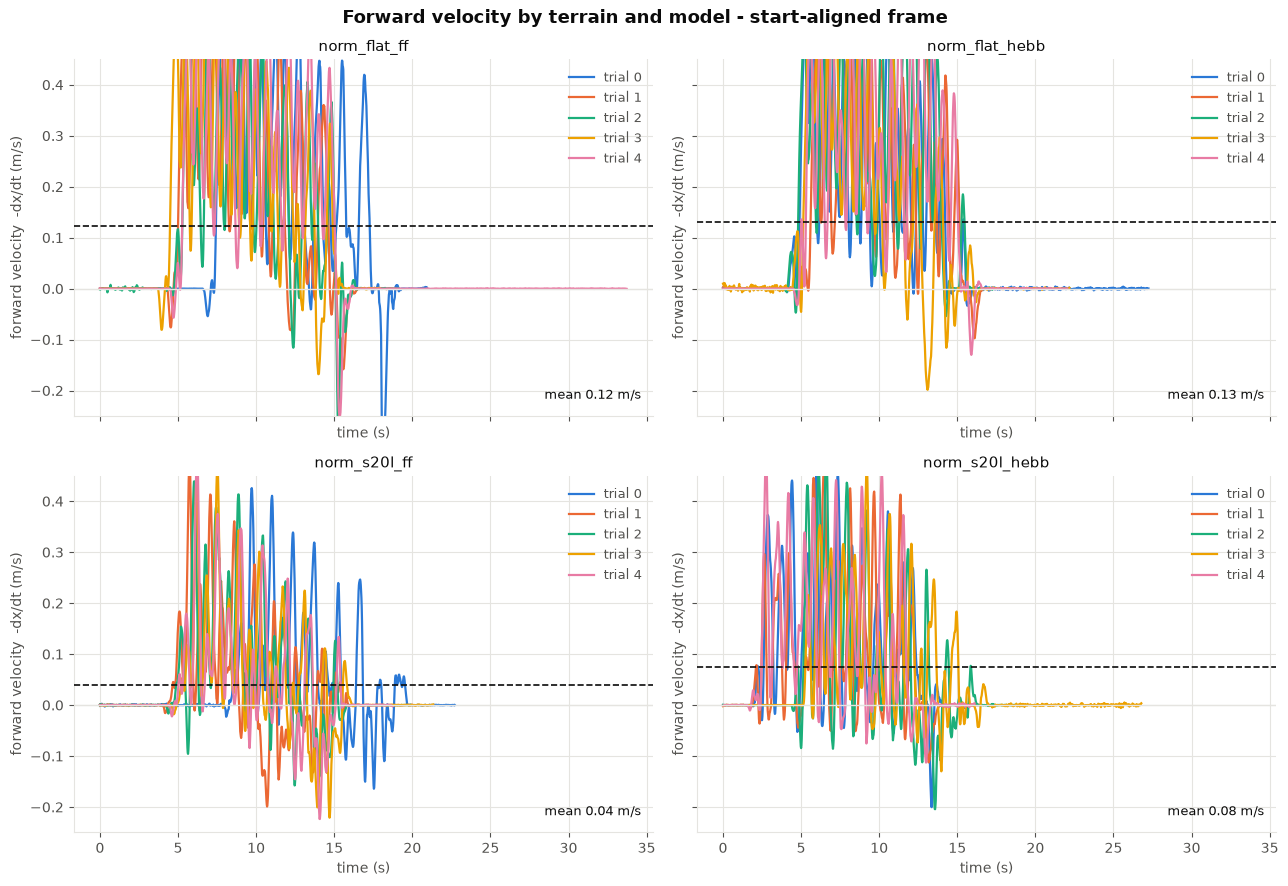

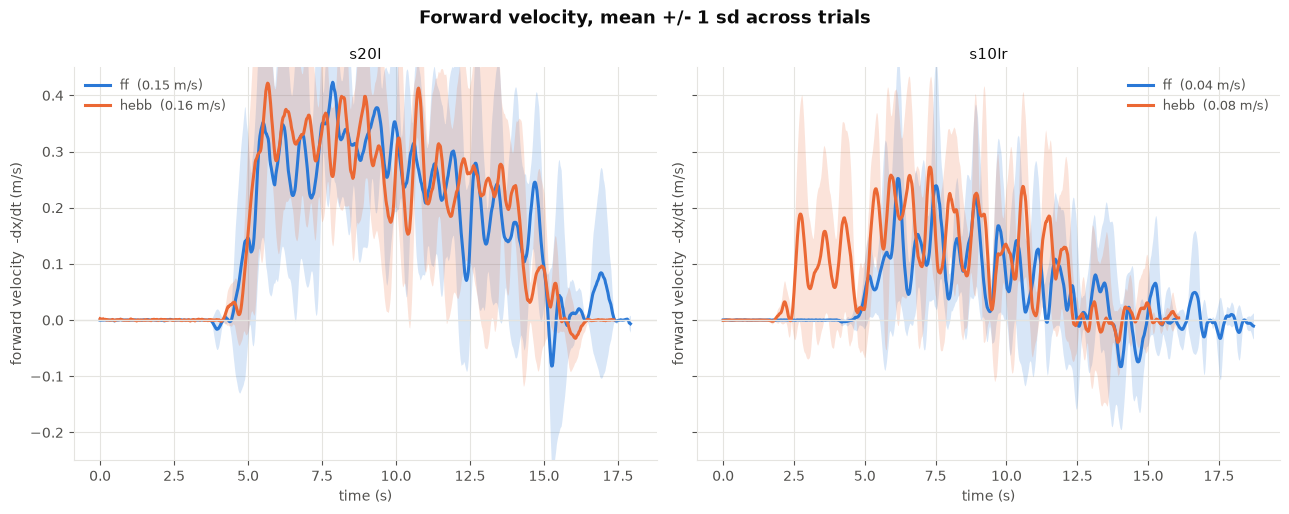

In [32]:
TRIAL_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#e5e4e0'

if True:
    fig, axs = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

    for i, ax in enumerate(axs.flatten()):
        for j, (t, v) in enumerate(vel[i]):
            c = TRIAL_COLORS[j % len(TRIAL_COLORS)]
            ax.plot(t, v, color=c, lw=1.6, label=f'trial {TRIALS[j]}')

        # trial-averaged mean speed, so panels can be read against each other
        mbar = np.nanmean([np.nanmean(v) for _, v in vel[i]])
        ax.axhline(mbar, color=INK, lw=1.2, ls='--', zorder=4)
        ax.text(0.98, 0.04, f'mean {mbar:.2f} m/s', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9, color=INK)

        ax.axhline(0, color=GRID, lw=1)
        ax.set_xlabel('time (s)'); ax.set_ylabel('forward velocity  -dx/dt (m/s)')
        ax.set_title(f'{label[i]}', color=INK, fontsize=11)
        ax.set_ylim(-0.25, 0.45)

        ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
        for s in ('top', 'right'): ax.spines[s].set_visible(False)
        for s in ('left', 'bottom'): ax.spines[s].set_color(GRID)
        ax.tick_params(colors=INK_MUTED)
        ax.xaxis.label.set_color(INK_MUTED); ax.yaxis.label.set_color(INK_MUTED)

        ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED)

    fig.suptitle('Forward velocity by terrain and model - start-aligned frame',
                fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout()
    plt.show()

        # Same numbers, laid out to answer the actual question: ff against hebb on one
    # axis per terrain. Trials differ in length, so each is resampled onto a common
    # grid that stops at the shortest take rather than being padded.
    MODEL_COLORS = {'ff': '#2a78d6', 'hebb': '#eb6834'}

    def mean_band(runs, dt=0.02):
        t_end = min(t[-1] for t, _ in runs)
        grid = np.arange(0, t_end, dt)
        stack = np.vstack([np.interp(grid, t, v) for t, v in runs])
        return grid, stack.mean(0), stack.std(0, ddof=1)

    terrains = [('s20l', vel[0], vel[1]), ('s10lr', vel[2], vel[3])]

    fig, axs = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
    for ax, (name, ff, hebb) in zip(axs, terrains):
        for mdl, runs in (('ff', ff), ('hebb', hebb)):
            g, m, sd = mean_band(runs)
            c = MODEL_COLORS[mdl]
            ax.fill_between(g, m - sd, m + sd, color=c, alpha=0.18, lw=0)
            ax.plot(g, m, color=c, lw=2.2, label=f'{mdl}  ({m.mean():.2f} m/s)')

        ax.axhline(0, color=GRID, lw=1)
        ax.set_xlabel('time (s)'); ax.set_ylabel('forward velocity  -dx/dt (m/s)')
        ax.set_title(name, color=INK, fontsize=11)
        ax.set_ylim(-0.25, 0.45)

        ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
        for s in ('top', 'right'): ax.spines[s].set_visible(False)
        for s in ('left', 'bottom'): ax.spines[s].set_color(GRID)
        ax.tick_params(colors=INK_MUTED)
        ax.xaxis.label.set_color(INK_MUTED); ax.yaxis.label.set_color(INK_MUTED)
        ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED)

    fig.suptitle('Forward velocity, mean +/- 1 sd across trials',
                fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout()
    plt.show()



## Yaw

In [33]:
from scipy.spatial.transform import Rotation as Rot

# Every signal below returns [(time, y)] per trial, one list per entry of `data`,
# so the plot helpers in the next cell can draw any of them.
DECIMATE = 2      # takes are 100 Hz; every 2nd frame -> 50 Hz
SMOOTH_S = 0.2    # centred moving average, seconds

def _smooth(y, t, smooth_s):
    if not smooth_s:
        return y
    w = max(int(round(smooth_s / np.median(np.diff(t)))), 1)
    return pd.Series(y).rolling(w, center=True, min_periods=1).mean().to_numpy()

def forward_velocity(takes, decimate=DECIMATE, smooth_s=SMOOTH_S):
    """Forward speed from the start-aligned path, not raw pos_x: x_rel/z_rel are
    already translated to the start and turned so every take leaves the origin
    facing the same way, and the robot walks along -x, so -x_rel is forward."""
    out = []
    for df in takes:
        d = df.iloc[::decimate]
        t = d['time'].to_numpy(float)
        v = np.gradient(-d['x_rel'].to_numpy(float), t)   # centred, keeps len(t)
        out.append((t, _smooth(v, t, smooth_s)))
    return out

def heading(takes, decimate=DECIMATE):
    """Net turn since the start, radians, positive to the left. yaw_rel is
    already unwrapped and start-referenced by set_initial_position, so it is
    used raw: no smoothing and no conversion to degrees."""
    out = []
    for df in takes:
        d = df.iloc[::decimate]
        out.append((d['time'].to_numpy(float), d['yaw_rel'].to_numpy(float)))
    return out

def upright(takes, decimate=DECIMATE, smooth_s=SMOOTH_S):
    """Body vertical axis projected on the world vertical axis: 1.0 is perfectly
    level and the value is cos(tilt) in general, which is the upright term a
    reward uses.

    Motive exports Euler XYZ in degrees with Y up (see the take header) and the
    order is intrinsic. Read as extrinsic 'xyz' instead, the s20l takes come out
    inverted around 18-19 s while body height holds at 0.11 m, so that reading
    is wrong. Column 1 of the rotation matrix is the body +Y axis expressed in
    world coordinates, and its Y component is the projection on world up."""
    out = []
    for df in takes:
        d = df.iloc[::decimate]
        t = d['time'].to_numpy(float)
        e = np.deg2rad(d[['rot_x', 'rot_y', 'rot_z']].to_numpy(float))
        ok = np.isfinite(e).all(1)          # dropped frames stay NaN, not 0
        u = np.full(len(e), np.nan)
        u[ok] = Rot.from_euler('XYZ', e[ok]).as_matrix()[:, 1, 1]
        out.append((t, _smooth(u, t, smooth_s)))
    return out

vel = [forward_velocity(takes) for takes in data]
yaw = [heading(takes) for takes in data]
upr = [upright(takes) for takes in data]


In [34]:
# Roughly half of every take is the robot standing still, before the gait starts
# and after it stops, and that idle time is not free: the yaw penalty keeps
# accruing on a robot that has already finished turning. Keep the walking bout
# only, defined as the longest stretch whose ground speed holds above MOVE_MIN.
MOVE_MIN, GAP_S = 0.03, 0.5   # m/s and seconds; resting noise sits under 0.015 m/s

def ground_speed(takes, decimate=DECIMATE, smooth_s=SMOOTH_S):
    """Speed in the ground plane, so a turn in place or a sideways shuffle counts
    as motion the same way a forward walk does."""
    out = []
    for df in takes:
        d = df.iloc[::decimate]
        t = d['time'].to_numpy(float)
        vx = np.gradient(d['x_rel'].to_numpy(float), t)
        vz = np.gradient(d['z_rel'].to_numpy(float), t)
        out.append((t, _smooth(np.hypot(vx, vz), t, smooth_s)))
    return out

def _runs(mask):
    """[(start, stop)] for each contiguous True stretch."""
    edge = np.diff(np.r_[0, mask.astype(int), 0])
    return list(zip(np.flatnonzero(edge == 1), np.flatnonzero(edge == -1)))

def motion_window(t, speed, thresh=MOVE_MIN, gap_s=GAP_S):
    """(i0, i1) around the walking bout. Interior dips shorter than gap_s are
    closed first, so the slow phase of a gait cycle cannot split the bout, and
    the longest surviving run wins, so a marker glitch at t=0 cannot claim it."""
    moving = np.nan_to_num(speed) > thresh
    gap = max(int(round(gap_s / np.median(np.diff(t)))), 1)
    for a, b in _runs(~moving):
        if a > 0 and b < len(moving) and b - a <= gap:
            moving[a:b] = True
    runs = _runs(moving)
    return max(runs, key=lambda r: r[1] - r[0]) if runs else (0, len(t))

def trim(series, windows):
    """Cut a signal to its window and restart the clock at motion onset, so
    trials line up on the first step rather than on the start of recording."""
    return [[(t[i0:i1] - t[i0], y[i0:i1])
             for (t, y), (i0, i1) in zip(cond, w)]
            for cond, w in zip(series, windows)]

# Rebuilt from `data` rather than trimmed in place, so re-running is harmless.
windows = [[motion_window(t, s) for t, s in ground_speed(takes)] for takes in data]
vel = trim([forward_velocity(takes) for takes in data], windows)
yaw = trim([heading(takes) for takes in data], windows)
upr = trim([upright(takes) for takes in data], windows)

print(f"{'condition':17}{'onset (s)':>11}{'bout (s)':>10}{'kept':>7}")
for name, w, takes in zip(label, windows, [ground_speed(t) for t in data]):
    on = [t[i0] for (t, _), (i0, _) in zip(takes, w)]
    dur = [t[i1 - 1] - t[i0] for (t, _), (i0, i1) in zip(takes, w)]
    kept = [(i1 - i0) / len(t) for (t, _), (i0, i1) in zip(takes, w)]
    print(f'{name:17}{np.mean(on):11.1f}{np.mean(dur):10.1f}{np.mean(kept):7.0%}')


condition          onset (s)  bout (s)   kept
norm_flat_ff             4.8      11.7    56%
norm_flat_hebb           4.5      11.1    53%
norm_s20l_ff             5.2      11.3    55%
norm_s20l_hebb           3.1      11.2    61%
norm_s10lr_ff            4.6      11.2    59%
norm_s10lr_hebb          5.3      10.6    51%


In [35]:
TRIAL_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
MODEL_COLORS = {'ff': '#2a78d6', 'hebb': '#eb6834'}
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#e5e4e0'

def _style(ax, ylabel, title, ylim):
    ax.axhline(0, color=GRID, lw=1)
    ax.set_xlabel('time (s)'); ax.set_ylabel(ylabel)
    ax.set_title(title, color=INK, fontsize=11)
    if ylim: ax.set_ylim(*ylim)
    ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED)
    ax.xaxis.label.set_color(INK_MUTED); ax.yaxis.label.set_color(INK_MUTED)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED)

def _terrains(names):
    """Group the entries of `label` by terrain, keeping the order they appear in.
    'norm_s20l_hebb' -> terrain 's20l', model 'hebb', so the layout follows
    whichever four or six conditions `data` currently holds."""
    order, groups = [], {}
    for i, n in enumerate(names):
        terrain, _, model = n.replace('norm_', '').rpartition('_')
        groups.setdefault(terrain, {})[model] = i
        if terrain not in order: order.append(terrain)
    return [(t, groups[t]) for t in order]

def _summary(runs, stat):
    """stat='mean' for a level, 'final' for where a cumulative curve ends."""
    if stat == 'final':
        return np.nanmean([y[-1] for _, y in runs]), 'final '
    return np.nanmean([np.nanmean(y) for _, y in runs]), 'mean '

def _panel_order(n, layout):
    """Panel index for each cell of the grid, None where a cell stays empty.
    'model' gives one row per model, ff on top, one column per terrain.
    'data' fills two rows in the order `data` happens to be written."""
    if layout == 'model':
        groups = _terrains(label)
        models = list(dict.fromkeys(m for _, g in groups for m in g))
        order = [g.get(m) for m in models for _, g in groups]
        return order, len(models), len(groups)
    ncols = -(-n // 2)
    return list(range(n)) + [None] * (2 * ncols - n), 2, ncols

def grid_panels(series, ylabel, suptitle, ylim=None, fmt='{:.2f}', stat='mean',
                layout='data'):
    """One panel per condition, one line per trial, in the trajectory-plot style."""
    order, nrows, ncols = _panel_order(len(series), layout)
    fig, axs = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows),
                            sharex=True, sharey=True, squeeze=False)
    for i, ax in zip(order, axs.flatten()):
        if i is None:
            ax.set_visible(False); continue
        for j, (t, y) in enumerate(series[i]):
            ax.plot(t, y, color=TRIAL_COLORS[j % len(TRIAL_COLORS)], lw=1.6,
                    label=f'trial {TRIALS[j]}')
        # trial-averaged level, so panels can be read against each other
        mbar, tag = _summary(series[i], stat)
        ax.axhline(mbar, color=INK, lw=1.2, ls='--', zorder=4)
        ax.text(0.98, 0.04, tag + fmt.format(mbar), transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9, color=INK)
        _style(ax, ylabel, label[i], ylim)
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout(); plt.show()

def mean_band(runs, dt=0.02):
    """Trials differ in length, so each is resampled onto a common grid that
    stops at the shortest take rather than being padded. Dropped frames are
    interpolated across rather than carried through: np.interp would spread a
    single NaN over the whole mean."""
    grid = np.arange(0, min(t[-1] for t, _ in runs), dt)
    stack = np.vstack([np.interp(grid, t[np.isfinite(y)], y[np.isfinite(y)])
                       for t, y in runs])
    return grid, stack.mean(0), stack.std(0, ddof=1)

def compare_models(series, ylabel, suptitle, ylim=None, fmt='{:.2f}', stat='mean'):
    """ff against hebb on one axis per terrain, mean +/- 1 sd across trials."""
    groups = _terrains(label)
    fig, axs = plt.subplots(1, len(groups), figsize=(6.5 * len(groups), 5.2),
                            sharey=True, squeeze=False)
    for ax, (name, models) in zip(axs.flatten(), groups):
        for mdl, i in models.items():
            g, m, sd = mean_band(series[i])
            c = MODEL_COLORS.get(mdl, INK_MUTED)
            ax.fill_between(g, m - sd, m + sd, color=c, alpha=0.18, lw=0)
            v = m[-1] if stat == 'final' else m.mean()
            ax.plot(g, m, color=c, lw=2.2,
                    label=f'{mdl}  (' + fmt.format(v) + ')')
        _style(ax, ylabel, name, ylim)
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout(); plt.show()


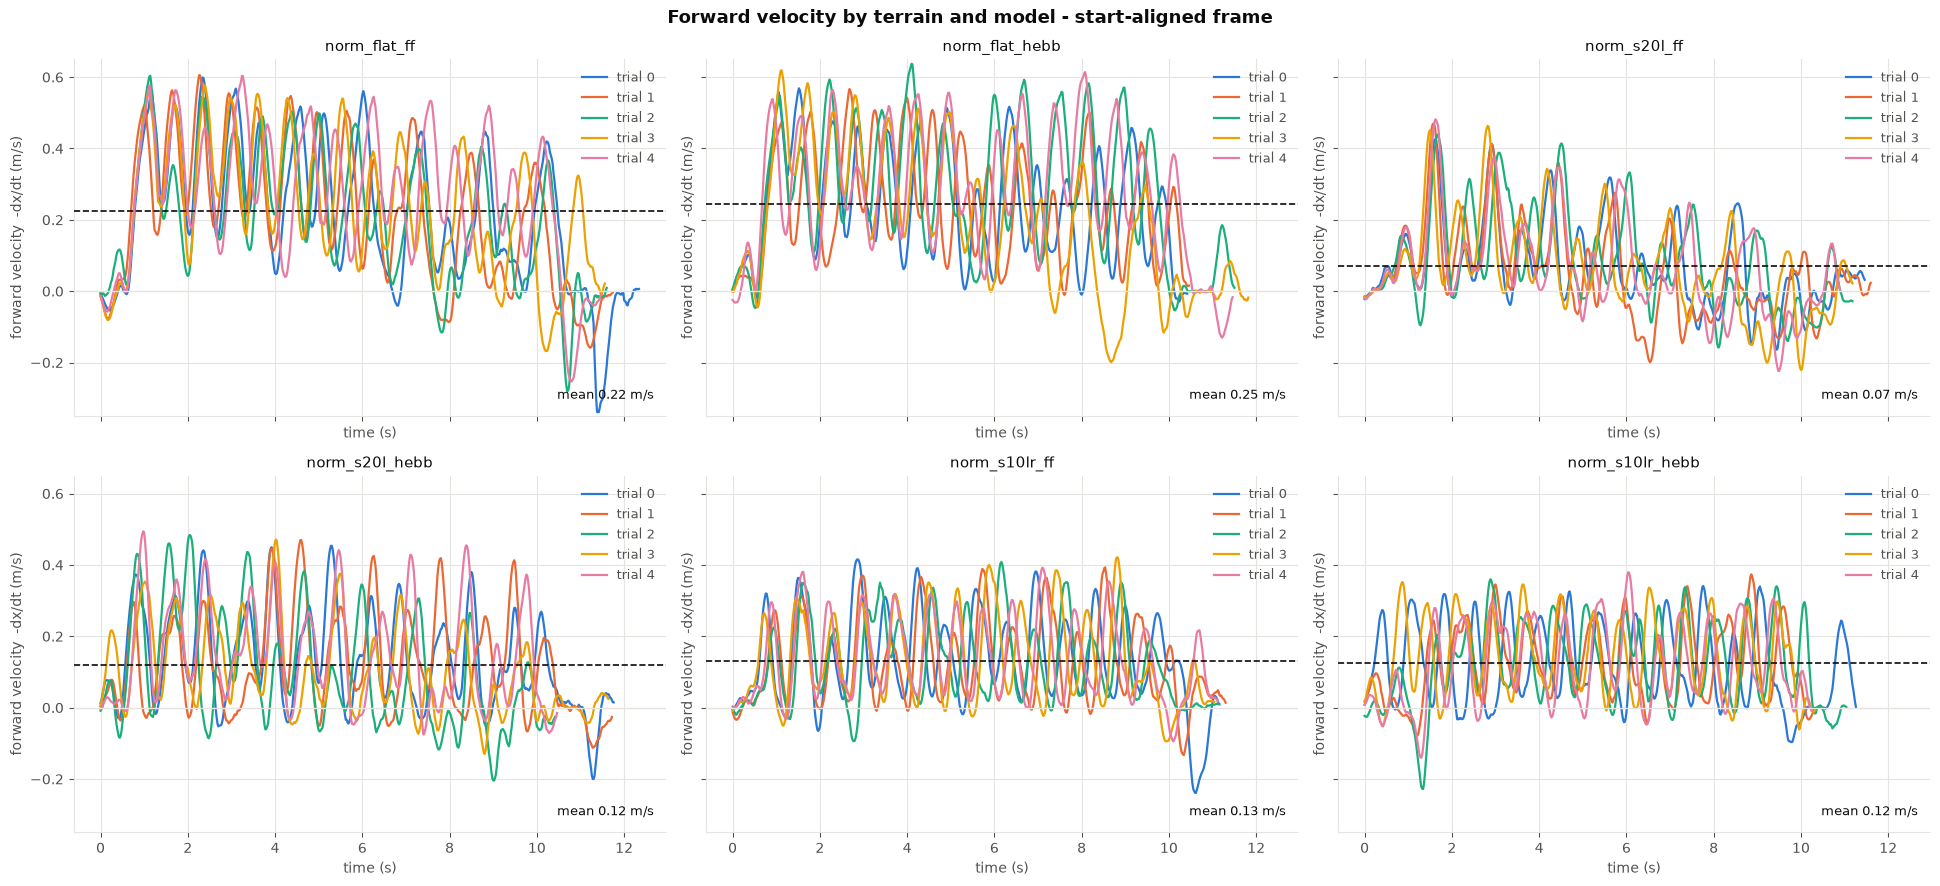

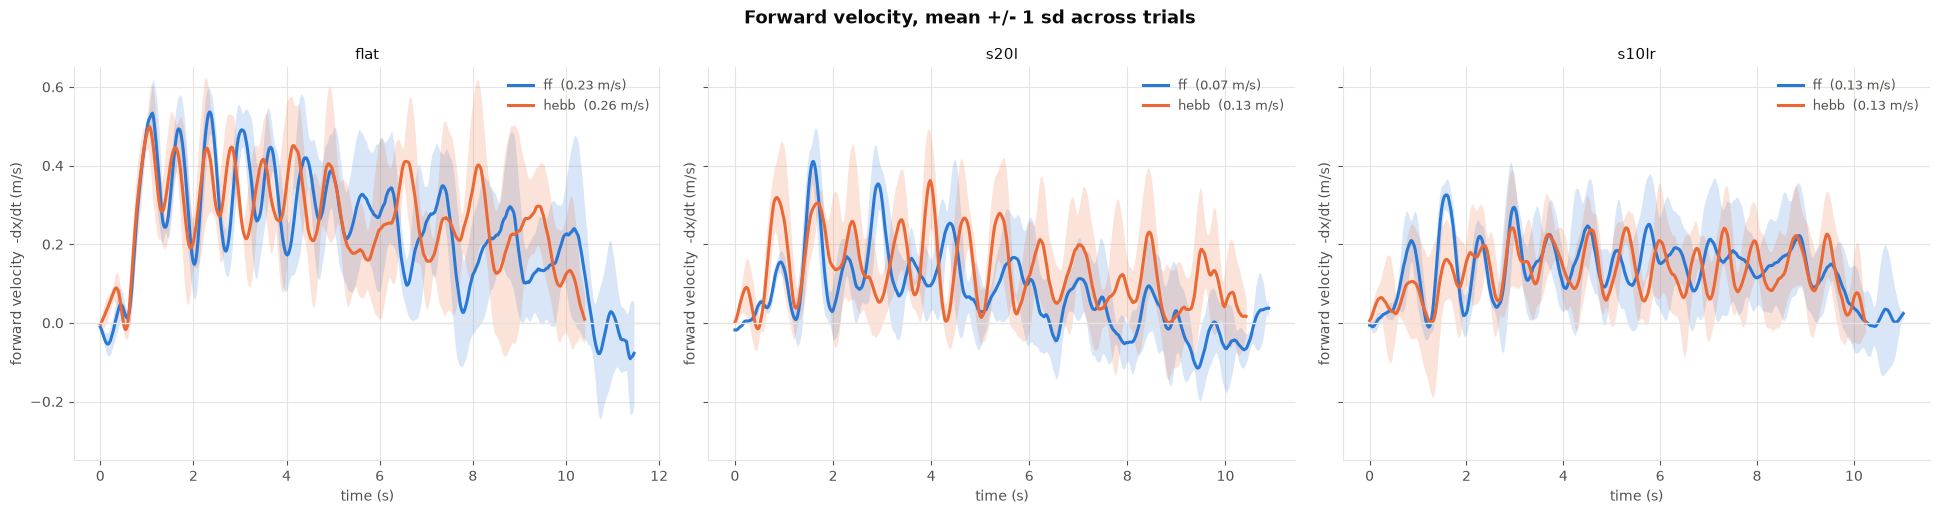

In [36]:
V_LABEL, V_LIM = 'forward velocity  -dx/dt (m/s)', (-0.35, 0.65)
grid_panels(vel, V_LABEL, 'Forward velocity by terrain and model - start-aligned frame',
            V_LIM, fmt='{:.2f} m/s')
compare_models(vel, V_LABEL, 'Forward velocity, mean +/- 1 sd across trials',
               V_LIM, fmt='{:.2f} m/s')


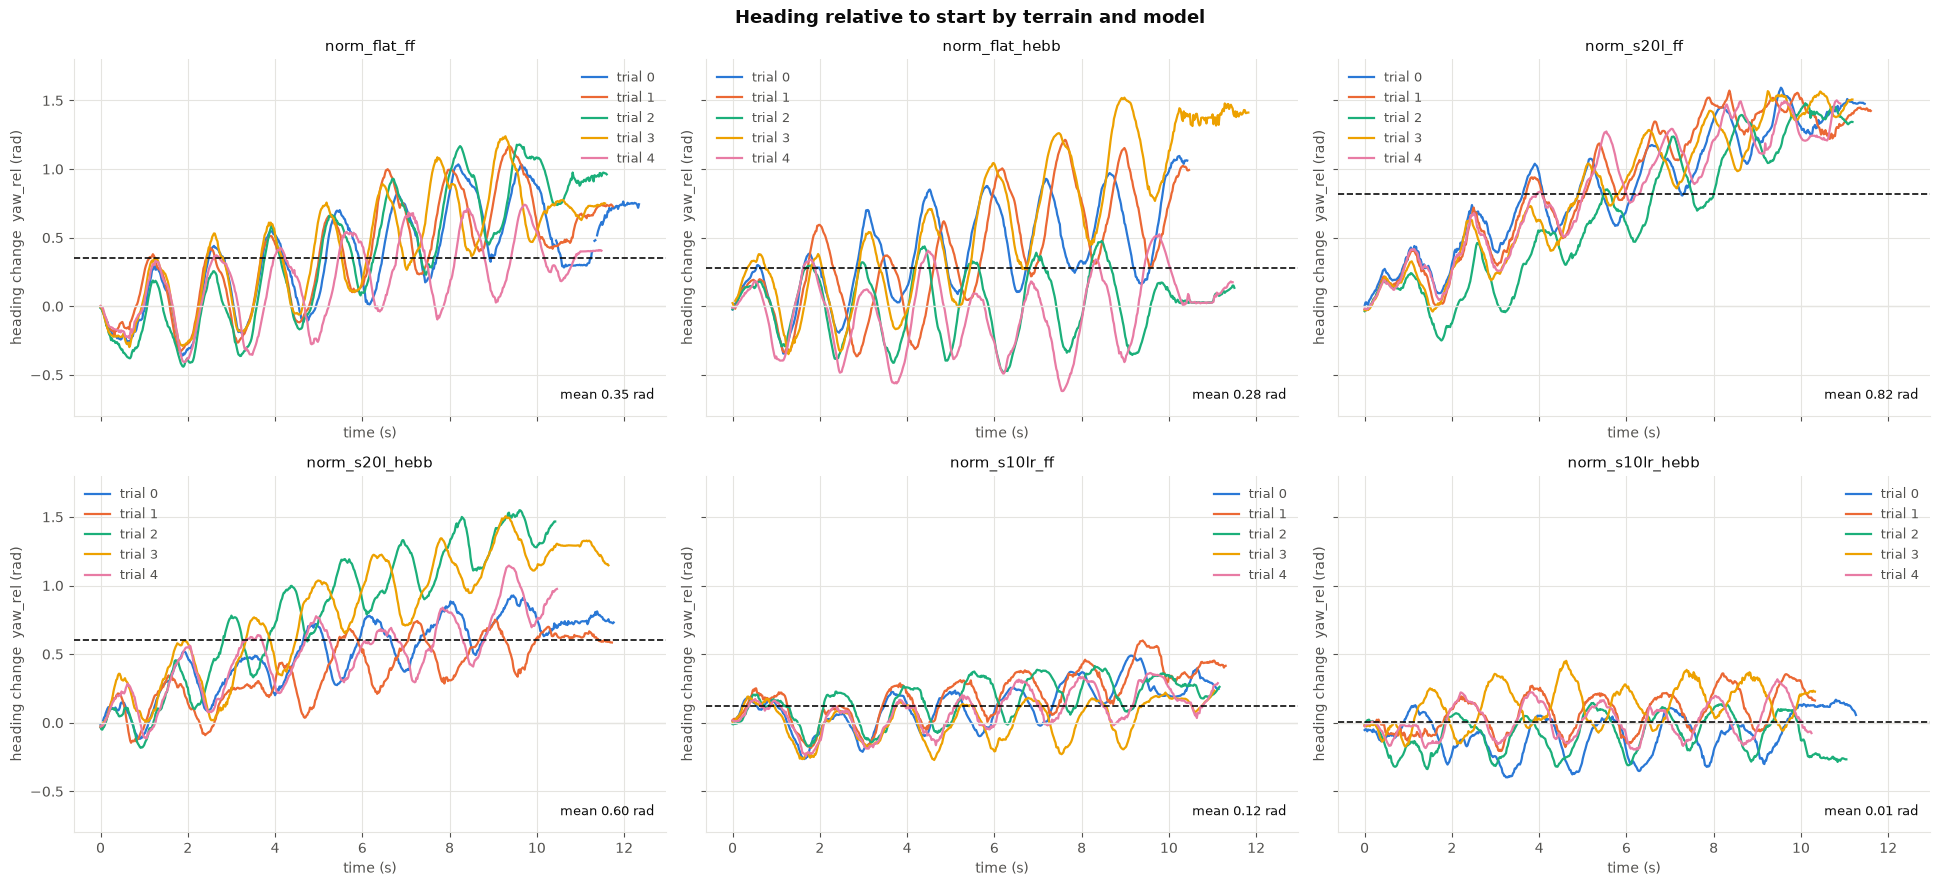

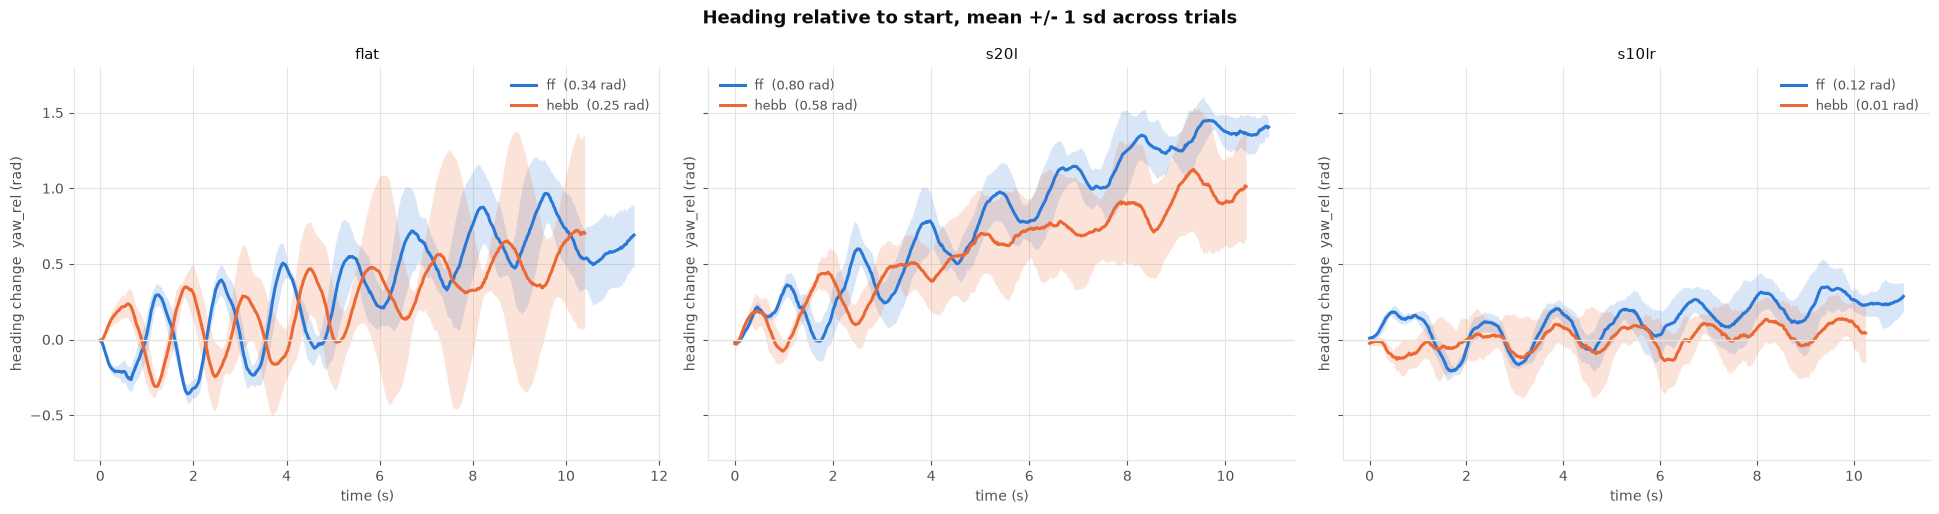

In [37]:
# Radians, not degrees: yaw_rel is 0 at the start of every take, so a flat line
# is a straight walk and the sign says which way the robot drifted.
Y_LABEL, Y_LIM = 'heading change  yaw_rel (rad)', (-0.8, 1.8)
grid_panels(yaw, Y_LABEL, 'Heading relative to start by terrain and model',
            Y_LIM, fmt='{:.2f} rad')
compare_models(yaw, Y_LABEL, 'Heading relative to start, mean +/- 1 sd across trials',
               Y_LIM, fmt='{:.2f} rad')


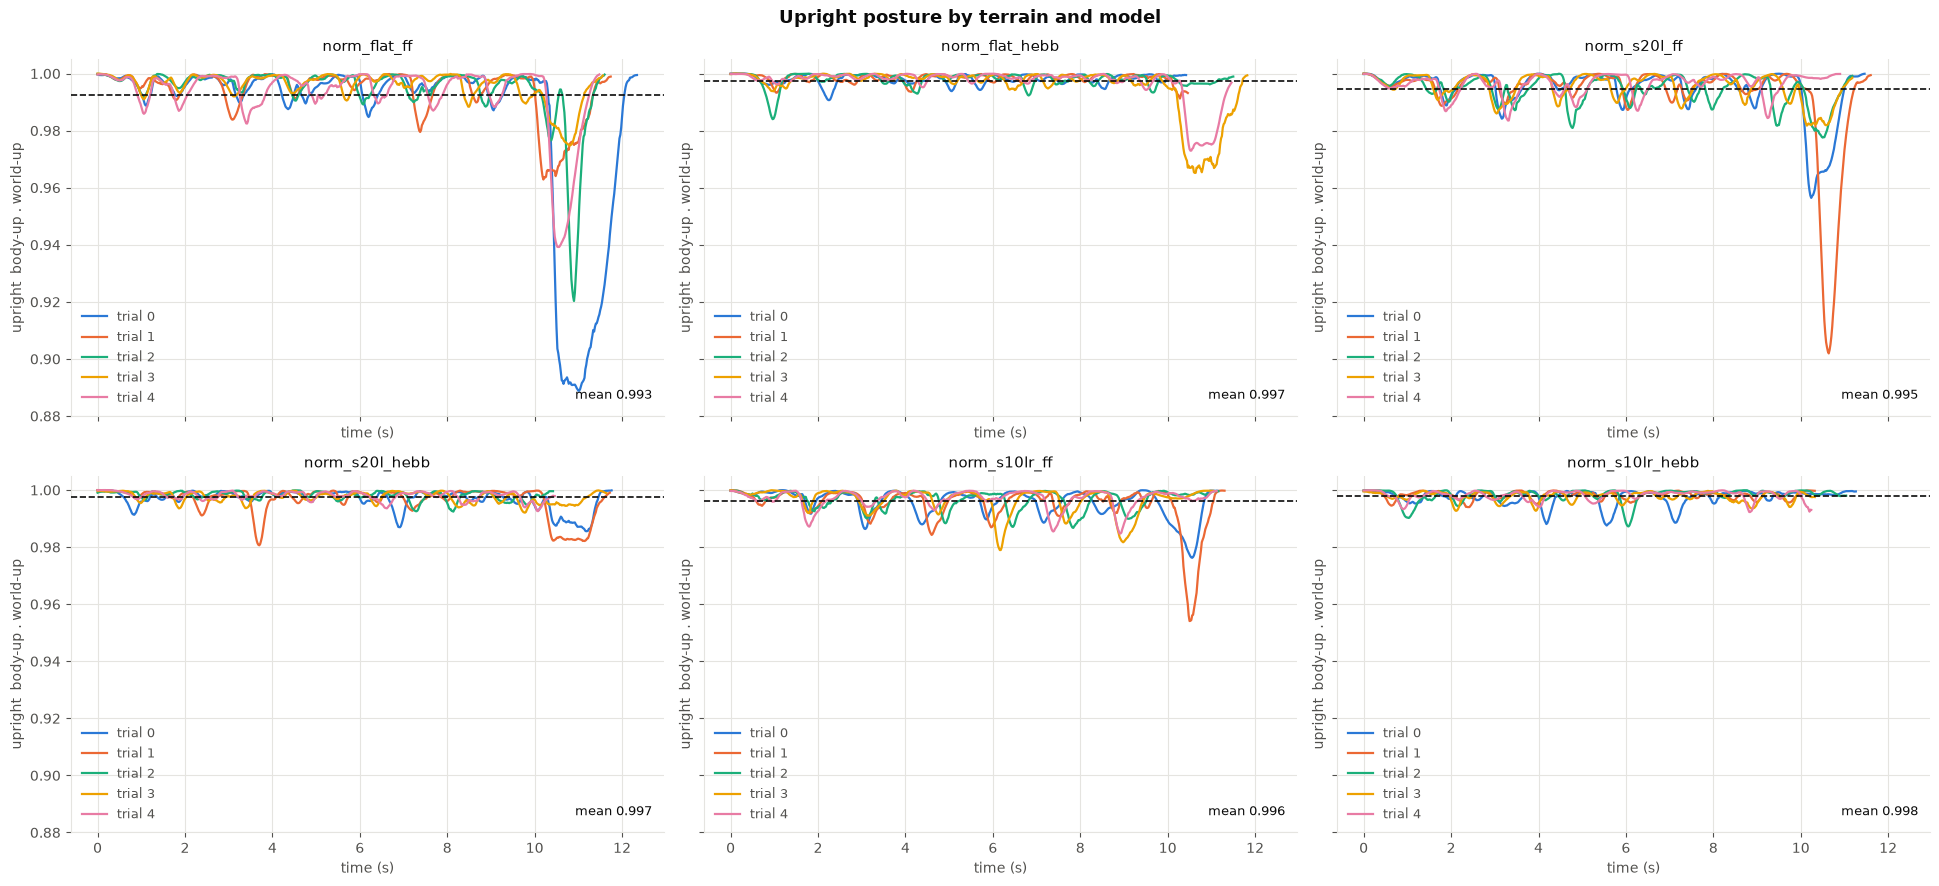

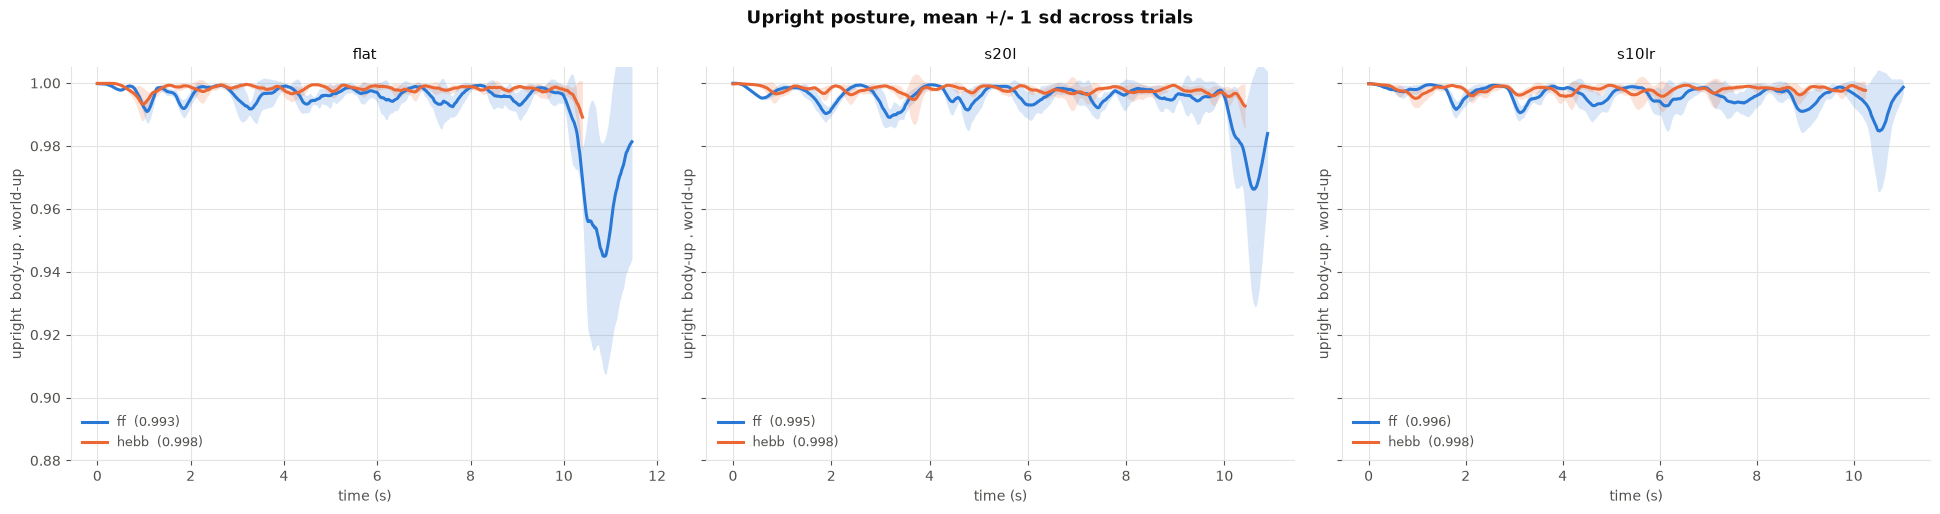

norm_flat_ff     mean tilt  5.42 deg   worst  27.3 deg
norm_flat_hebb   mean tilt  3.47 deg   worst  15.2 deg
norm_s20l_ff     mean tilt  4.96 deg   worst  25.6 deg
norm_s20l_hebb   mean tilt  3.69 deg   worst  11.3 deg
norm_s10lr_ff    mean tilt  4.38 deg   worst  17.4 deg
norm_s10lr_hebb  mean tilt  3.31 deg   worst   9.2 deg


In [38]:
# Upright term: body up axis dotted with world up, so 1.0 is level and the drop
# below 1 is the cosine of the tilt angle. Absolute, never start-referenced.
U_LABEL, U_LIM = 'upright  body-up . world-up', (0.88, 1.005)
grid_panels(upr, U_LABEL, 'Upright posture by terrain and model',
            U_LIM, fmt='{:.3f}')
compare_models(upr, U_LABEL, 'Upright posture, mean +/- 1 sd across trials',
               U_LIM, fmt='{:.3f}')

# The same signal as a tilt angle, for the numbers that go in the text.
for name, runs in zip(label, upr):
    tilt = np.rad2deg(np.arccos(np.clip(np.concatenate([u for _, u in runs]), -1, 1)))
    print(f'{name:16} mean tilt {np.nanmean(tilt):5.2f} deg   worst {np.nanmax(tilt):5.1f} deg')


## Reward

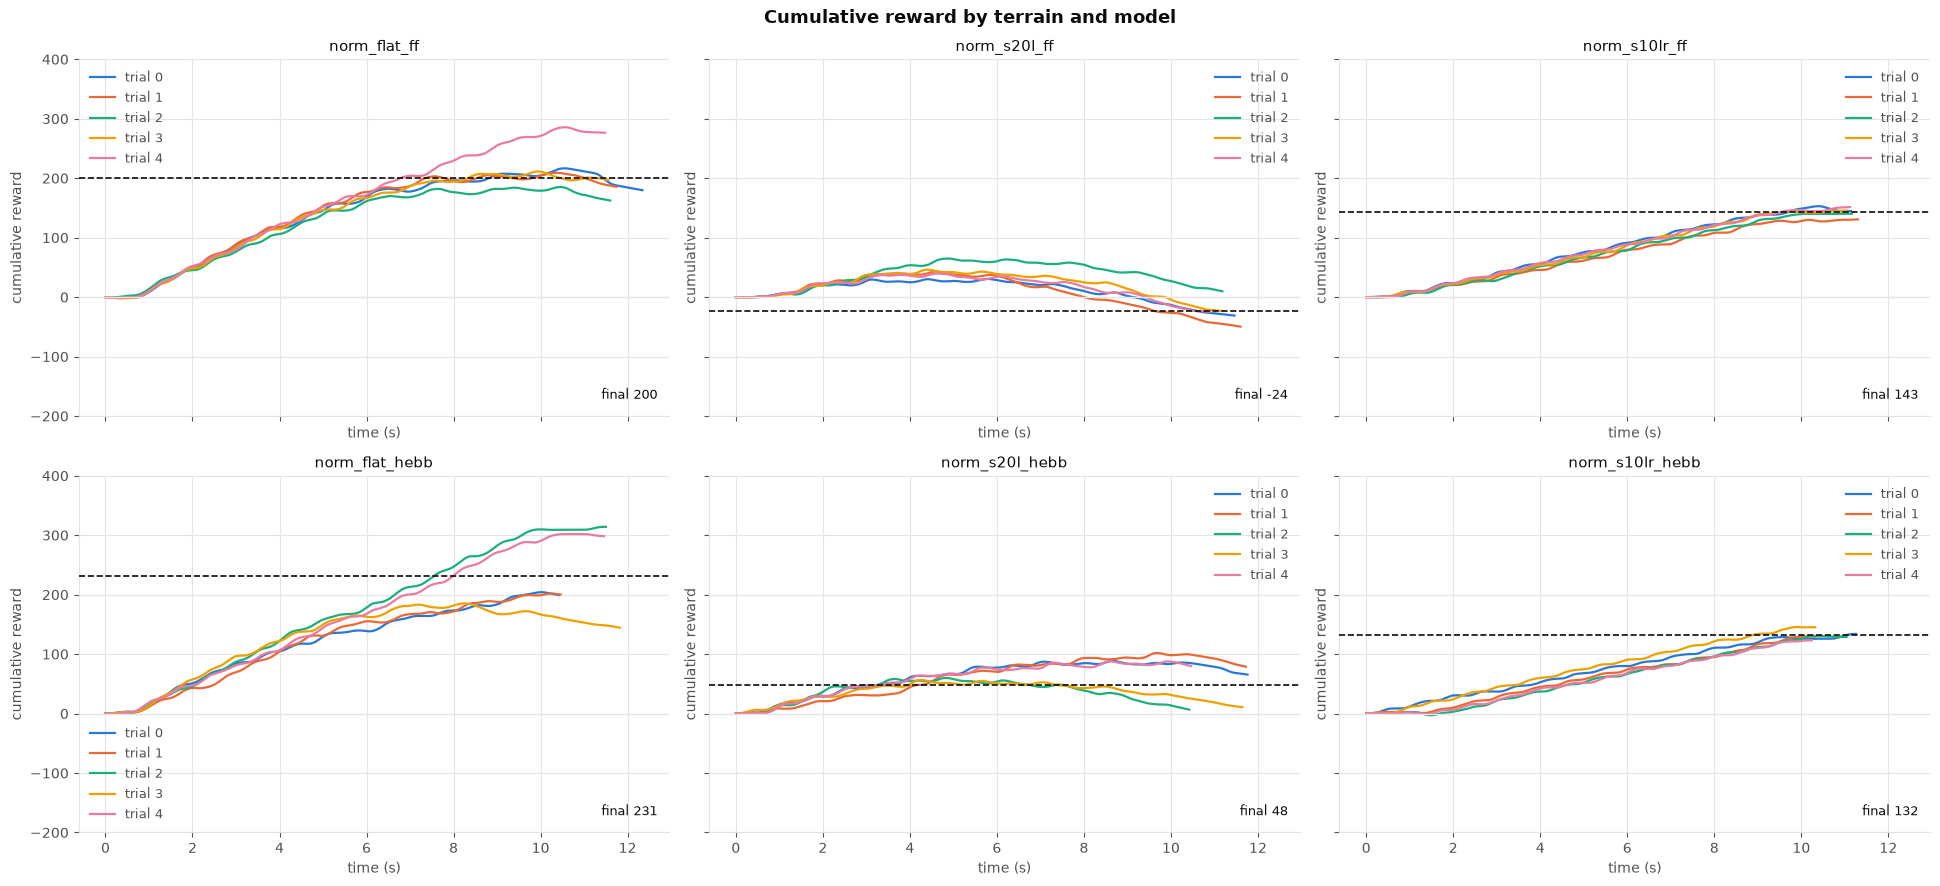

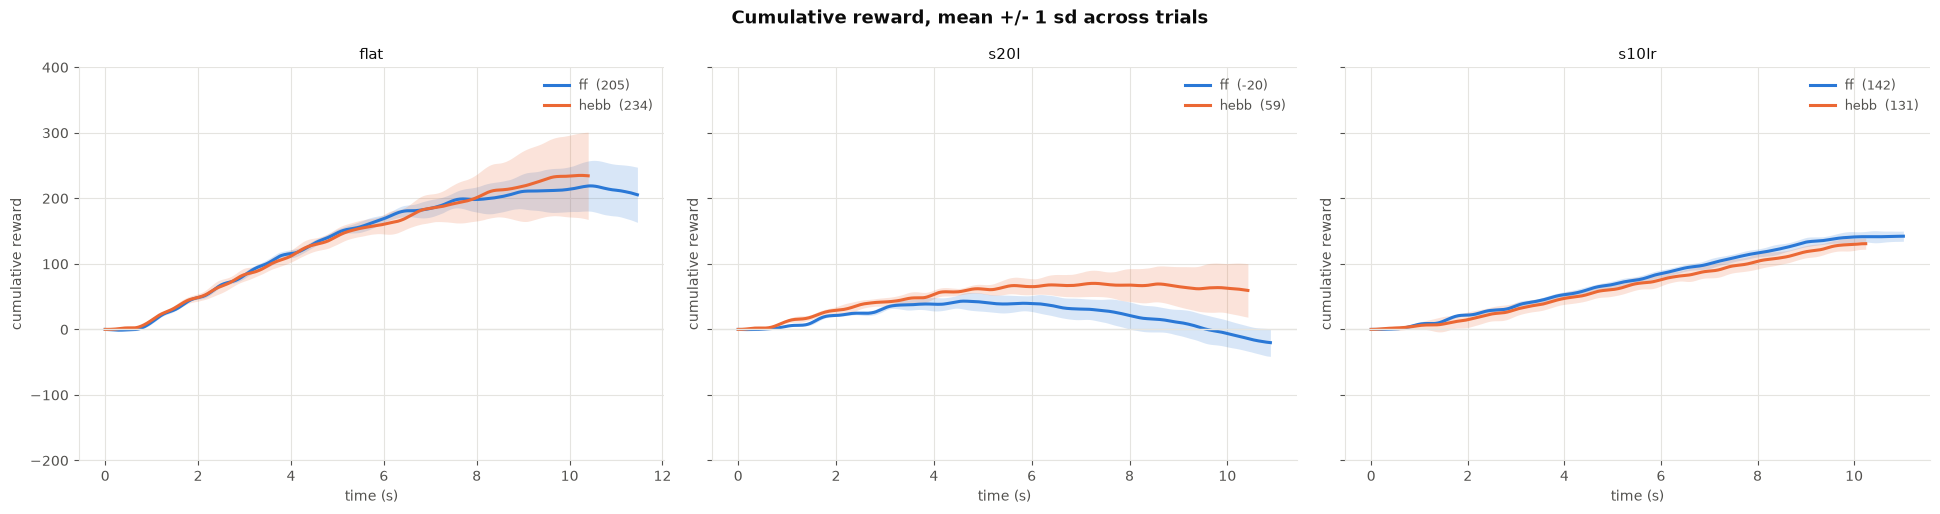

In [39]:
# Reward evaluated per control sample, then accumulated. DECIMATE = 2 puts the
# samples at 50 Hz, so one unit of cumulative reward is one 20 ms step.
#   upright   0 while body-up . world-up > 0.93, else -0.5
#   velocity  the forward speed itself, m/s
#   yaw       0 while |yaw_rel| < 0.45 rad, else -0.5
UPRIGHT_MIN, YAW_LIM, PENALTY = 0.93, 0.45, -0.5
k_v , k_y , k_u = 2.0 , 0.5 ,0.5

def reward_terms(v_c, y_c, u_c, k_v , k_y, k_u):
    """[(time, {term: r}, r_total)] per trial. The three signals are read off the
    same decimated frames, so they share a time base and add sample by sample."""
    out = []
    for (t, v), (_, y), (_, u) in zip(v_c, y_c, u_c):
        parts = {
            # a dropped frame scores nothing rather than tripping a threshold it
            # cannot be tested against
            'velocity': k_v * np.nan_to_num(v),
            'upright': np.where(np.isfinite(u) & (u <= UPRIGHT_MIN), k_u * PENALTY, 0.0),
            'yaw': np.where(np.isfinite(y) & (np.abs(y) >= YAW_LIM), k_y * PENALTY, 0.0),
        }
        out.append((t, parts, sum(parts.values())))
    return out

rew = [reward_terms(v, y, u , k_v , k_y , k_u) for v, y, u in zip(vel, yaw, upr)]
cum = [[(t, np.cumsum(r)) for t, _, r in trials] for trials in rew]

R_LABEL, R_LIM = 'cumulative reward', (-200, 400)
grid_panels(cum, R_LABEL, 'Cumulative reward by terrain and model',
            R_LIM, fmt='{:.0f}', stat='final', layout='model')
compare_models(cum, R_LABEL, 'Cumulative reward, mean +/- 1 sd across trials',
               R_LIM, fmt='{:.0f}', stat='final')


In [40]:
# Which term actually moves the return, averaged over trials. The yaw penalty
# accrues at -0.5 every 20 ms once the heading passes 0.45 rad and never recovers,
# so it outweighs the velocity term wherever the robot turns.
print(f"{'condition':17}{'return':>9}{'velocity':>10}{'upright':>9}{'yaw':>8}   {'penalised':>9}")
for name, trials in zip(label, rew):
    total = np.mean([r.sum() for _, _, r in trials])
    part = {k: np.mean([p[k].sum() for _, p, _ in trials])
            for k in ('velocity', 'upright', 'yaw')}
    frac = np.mean([np.mean((p['yaw'] + p['upright']) != 0) for _, p, _ in trials])
    print(f"{name:17}{total:9.1f}{part['velocity']:10.1f}{part['upright']:9.1f}"
          f"{part['yaw']:8.1f}   {frac:8.0%}")


condition           return  velocity  upright     yaw   penalised
norm_flat_ff         200.3     263.5     -3.2   -60.0        42%
norm_flat_hebb       231.2     273.4      0.0   -42.2        31%
norm_s20l_ff         -23.8      78.9     -0.8  -101.9        72%
norm_s20l_hebb        48.4     135.0      0.0   -86.7        62%
norm_s10lr_ff        142.5     145.2      0.0    -2.7         2%
norm_s10lr_hebb      132.1     132.2      0.0    -0.1         0%
